In [13]:
import numpy as np
import matplotlib.pyplot as plt

In [14]:
c0 = 1.0
sigma_r = 1e-3
zr = np.array([-5.0, 0.0, 65.0])
N_sources = 200
n_receivers = 5

In [15]:
dw = 0.05
omegas = np.arange(-5, 5, dw)
sources = np.zeros((N_sources, 3))
sources[:, 0] = np.random.uniform(-50, 50, N_sources)   # x-coordinates
sources[:, 1] = np.random.uniform(-10, 10, N_sources)   # y-coordinates
sources[:, 2] = np.random.uniform(185, 200, N_sources)  # z-coordinates  a regarder
taus = np.linspace(-200, 200, 400)

In [16]:
n_receivers = 5
receivers = np.zeros((n_receivers, 3))

for j in range(n_receivers):
    # We use j because Python indexing starts at 0 
    # This corresponds exactly to (j-1) in the document's formula
    x_coord = -30 + 7.5 * j
    y_coord = 0
    z_coord = 100
    
    receivers[j] = np.array([x_coord, y_coord, z_coord])

# To access receiver x1 and x5 as requested in the first question:
x1 = receivers[0]
x5 = receivers[4]

In [17]:
def F(w):
    return np.exp(-w**2)

In [18]:
def G0(w,x,y):
    distance = np.linalg.norm(x-y)
    coefficient= 1/(4*np.pi*distance)
    exposant = 1j*w*distance/c0
    return coefficient*np.exp(exposant)

In [19]:
def G(w,x,y):
    G0_xy= G0(w,x,y)
    G0_xzr= G0(w,x,zr)
    G0_zry= G0(w,zr,y)
    return G0_xy + sigma_r*(w**2)*G0_xzr*G0_zry

In [20]:
def CN(tau,x1,x2):
    summ=0
    for s in range(N_sources):
        ys=sources[s]
        G_x1ys= G(omegas,x1,ys)
        G_x2ys= G(omegas,x2,ys)
        integrand=F(omegas)*np.conj(G_x1ys)*G_x2ys*np.exp(-1j*omegas*tau)
        integral=np.sum(integrand)*dw
        summ+=integral
    return summ/(2*np.pi*N_sources)

c:\Users\athee\AppData\Local\Programs\Python\Python310\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\athee\AppData\Local\Programs\Python\Python310\lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


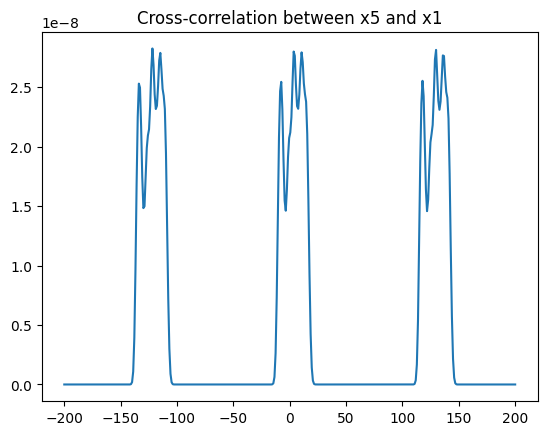

In [21]:
results = [CN(t, receivers[4], receivers[0]) for t in taus]
plt.plot(taus, results)
plt.title("Cross-correlation between x5 and x1")
plt.show()

In [22]:
dist_samples = np.linspace(0, 200, 1000)
CN_matrix = np.zeros((n_receivers, n_receivers, len(dist_samples)))

print("Building CN Lookup Matrix using your function...")

# We loop over pairs (25) and distances (1000) = 25,000 calls
# (Much better than 62,500 calls in the main loop!)
for j in range(n_receivers):
    for l in range(n_receivers):
        # For this pair, calculate CN for all distances
        # We assume your CN can take a single distance 'd'
        for d_idx, d in enumerate(dist_samples):
            CN_matrix[j, l, d_idx] = CN(d, receivers[j], receivers[l])
def Km(ys):
    summ=0
    for j in range(n_receivers):
        for l in range(n_receivers):
            distance= np.linalg.norm(receivers[j]-ys)+np.linalg.norm(receivers[l]-ys)
            summ+=np.interp(dist, dist_samples, CN_matrix[j, l])
    return summ

Building CN Lookup Matrix using your function...


C:\Users\athee\AppData\Local\Temp\ipykernel_40216\2358691006.py:13: ComplexWarning: Casting complex values to real discards the imaginary part
  CN_matrix[j, l, d_idx] = CN(d, receivers[j], receivers[l])


KeyboardInterrupt: 

Pre-computing CN source correlations...
Computing intensity grid...


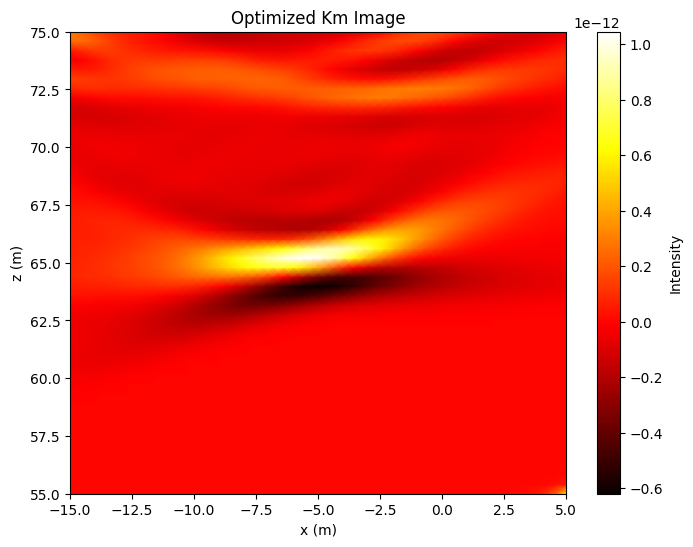

In [23]:
# --- 1. Pre-computation Step ---
# We calculate the "CN Kernel" for all receiver pairs (j, l) beforehand.
# This replaces the loop "for s in range(N_sources)" inside CN,
# running it 25 times instead of 2500 * 25 times.

print("Pre-computing CN source correlations...")

# Array to store Sum_s [ F(w) * G*(rj,s) * G(rl,s) ]
# Shape: (5 receivers, 5 receivers, Nw frequencies)
x_range = np.linspace(-15, 5, 50)   # 50 points along x
z_range = np.linspace(55, 75, 50)   # 50 points along z
X, Z = np.meshgrid(x_range, z_range)
Nw = len(omegas)
CN_kernels = np.zeros((n_receivers, n_receivers, Nw), dtype=complex)
F_w = F(omegas)

# Iterate sources ONCE
for s in range(N_sources):
    ys = sources[s]
    
    # Get Green's function from this source to all 5 receivers
    # G_rec_s[j] is vector of size Nw
    G_rec_s = [G(omegas, receivers[r], ys) for r in range(n_receivers)]
    
    # Add contribution to every pair (j, l)
    for j in range(n_receivers):
        G_j_conj = np.conj(G_rec_s[j])
        for l in range(n_receivers):
            # The integrand term from your CN function
            term = F_w * G_j_conj * G_rec_s[l]
            CN_kernels[j, l, :] += term

# Apply the normalization constant from your CN function
CN_kernels /= (2 * np.pi * N_sources)


# --- 2. Optimized Grid Loop ---
# Now we calculate Km for the grid. We use the pre-computed CN_kernels.
# This preserves the logic: summ += Integral( Kernel * exp(-i w tau) )

print("Computing intensity grid...")

# Prepare grid points (50x50 = 2500)
X_flat = X.ravel()
Z_flat = Z.ravel()
grid_points = np.stack([X_flat, np.zeros_like(X_flat), Z_flat], axis=1)
N_pixels = len(grid_points)

Intensity_flat = np.zeros(N_pixels)

# Iterate over receiver pairs (j, l)
for j in range(n_receivers):
    for l in range(n_receivers):
        # 1. Get the precomputed kernel for this pair (The heavy part of CN)
        H_wl = CN_kernels[j, l, :] # Shape (Nw,)
        
        # 2. Calculate distances (tau) for ALL pixels at once
        dist_j = np.linalg.norm(grid_points - receivers[j], axis=1)
        dist_l = np.linalg.norm(grid_points - receivers[l], axis=1)
        tau_grid = dist_j + dist_l # Shape (N_pixels,)
        
        # 3. Perform the Frequency Integral for all pixels
        # We need sum_w ( H_wl[w] * exp(-i * w * tau) ) * dw
        
        # Create phase matrix: -i * w * tau
        # Shape (Nw, N_pixels)
        phase_matrix = -1j * np.outer(omegas, tau_grid) / c0
        exp_matrix = np.exp(phase_matrix)
        
        # Dot product sums over frequency dimension (Nw)
        # (Nw) dot (Nw, N_pixels) -> (N_pixels)
        integral_values = np.dot(H_wl, exp_matrix) * dw
        
        # Add to total intensity (taking real part as Km output is summed)
        Intensity_flat += np.real(integral_values)

# Reshape back to image
Intensity = Intensity_flat.reshape(X.shape)

# Plotting
plt.figure(figsize=(8, 6))
plt.pcolormesh(X, Z, Intensity, shading='gouraud', cmap='hot')
plt.colorbar(label='Intensity')
plt.xlabel('x (m)')
plt.ylabel('z (m)')
plt.title('Optimized Km Image')
plt.show()

In [24]:
x_range = np.linspace(-15, 5, 50)  # 50 points for better resolution
z_range = np.linspace(55, 75, 50)
X, Z = np.meshgrid(x_range, z_range)
Intensity = np.zeros(X.shape)

# Fill the grid
for i in range(len(x_range)):
    for k in range(len(z_range)):
        search_point = np.array([x_range[i], 0, z_range[k]])
        Intensity[k, i] = Km(search_point)

# Plotting
plt.figure(figsize=(8, 6))
plt.pcolormesh(X, Z, Intensity, shading='gouraud', cmap='hot')
plt.colorbar(label='Intensity')
plt.scatter(zr[0], zr[2], color='cyan', marker='x', label='True Reflector') # Mark true location
plt.xlabel('x')
plt.ylabel('z')
plt.title('Kirchhoff Migration (KM) Image')
plt.legend()
plt.show()

NameError: name 'Km' is not defined

1. Pre-computing CN Matrix (Source Correlations)...
2. Computing Image Grid...
3. Plotting...


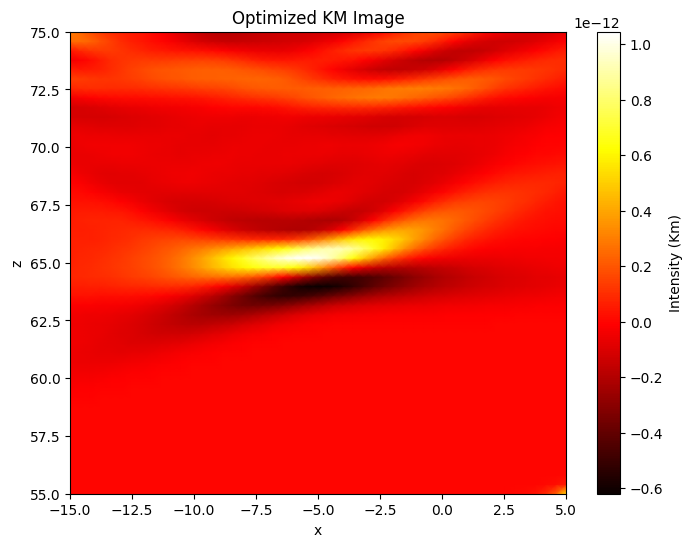

In [25]:
# Vectorized Green's Function
# Calculates Field between a point 'x' and a list of points 'y_array'
def G_vec(w, x, y_array):
    # x: (3,) single point
    # y_array: (N, 3) array of points
    
    # 1. Direct Path (x -> y)
    d_xy = np.linalg.norm(y_array - x, axis=1) # Shape (N,)
    coeff = 1.0 / (4 * np.pi * d_xy)
    # Broadcast w (Nw, 1) and d (1, N) -> (Nw, N)
    exp_xy = 1j * w[:, None] * d_xy[None, :] / c0
    G0_xy = coeff[None, :] * np.exp(exp_xy)

    # 2. Reflected Path (x -> zr -> y)
    # x -> zr
    d_xzr = np.linalg.norm(x - zr)
    G0_xzr = (1.0/(4*np.pi*d_xzr)) * np.exp(1j * w * d_xzr / c0)
    
    # zr -> y (all sources)
    d_zry = np.linalg.norm(y_array - zr, axis=1) # Shape (N,)
    G0_zry = (1.0/(4*np.pi*d_zry)[None, :]) * np.exp(1j * w[:, None] * d_zry[None, :] / c0)
    
    # Combine (sigma * w^2 * ...)
    # w**2 is (Nw,), reshape to (Nw, 1)
    term_refl = sigma_r * (w**2)[:, None] * G0_xzr[:, None] * G0_zry
    
    return G0_xy + term_refl

# --- 3. Pre-Calculate CN Matrix (The Optimization) ---
# We calculate the sum over sources ONCE for every receiver pair.
# This matrix replaces the 'for s in sources' loop inside CN.
print("1. Pre-computing CN Matrix (Source Correlations)...")

# Shape: (5 receivers, 5 receivers, Nw frequencies)
CN_Matrix = np.zeros((n_receivers, n_receivers, len(omegas)), dtype=complex)
F_w = F(omegas)[:, None] # Shape (Nw, 1)

# We use the vectorized G to compute all sources at once
for j in range(n_receivers):
    # Green's function from Receiver j to ALL sources: Shape (Nw, 200)
    G_j_all = G_vec(omegas, receivers[j], sources)
    
    for l in range(n_receivers):
        G_l_all = G_vec(omegas, receivers[l], sources)
        
        # Calculate the Term: F(w) * conj(G_j) * G_l
        # Multiply element-wise and SUM over sources (axis 1)
        # This one line replaces the loop over 200 sources!
        term = F_w * np.conj(G_j_all) * G_l_all
        CN_Matrix[j, l, :] = np.sum(term, axis=1)

# Normalize (as per your original function)
CN_Matrix /= (2 * np.pi * N_sources)


# --- 4. Main Grid Loop (Optimized Km) ---
print("2. Computing Image Grid...")

x_range = np.linspace(-15, 5, 50)
z_range = np.linspace(55, 75, 50)
X, Z = np.meshgrid(x_range, z_range)

# Flatten grid for speed (treat 2500 pixels as a list)
# Points: [[x0,0,z0], [x1,0,z1], ...]
X_flat = X.ravel()
Z_flat = Z.ravel()
grid_points = np.stack([X_flat, np.zeros_like(X_flat), Z_flat], axis=1)
N_pixels = len(grid_points)

Intensity_flat = np.zeros(N_pixels)

# Loop over receiver pairs (Only 25 iterations)
for j in range(n_receivers):
    for l in range(n_receivers):
        # A. Get the pre-calculated math for this pair
        H_w = CN_Matrix[j, l, :] # Shape (Nw,)
        
        # B. Calculate Geometry (Distances) for ALL pixels
        d_j = np.linalg.norm(grid_points - receivers[j], axis=1)
        d_l = np.linalg.norm(grid_points - receivers[l], axis=1)
        tau = d_j + d_l # Shape (N_pixels,)
        
        # C. Integrate over frequency (The Rest of CN)
        # exp(-i * w * tau) -> Shape (Nw, N_pixels)
        phase_shift = np.exp(-1j * omegas[:, None] * tau[None, :] / c0)
        
        # Sum( H(w) * phase_shift ) * dw
        # Dot product handles the sum over w
        integral = np.dot(H_w, phase_shift) * dw
        
        Intensity_flat += np.real(integral)

# Reshape back to image
Intensity = Intensity_flat.reshape(X.shape)

# --- 5. Plotting ---
print("3. Plotting...")
plt.figure(figsize=(8, 6))
plt.pcolormesh(X, Z, Intensity, shading='gouraud', cmap='hot')
plt.colorbar(label='Intensity (Km)')
plt.xlabel('x')
plt.ylabel('z')
plt.title('Optimized KM Image')
plt.show()

Computing Image...


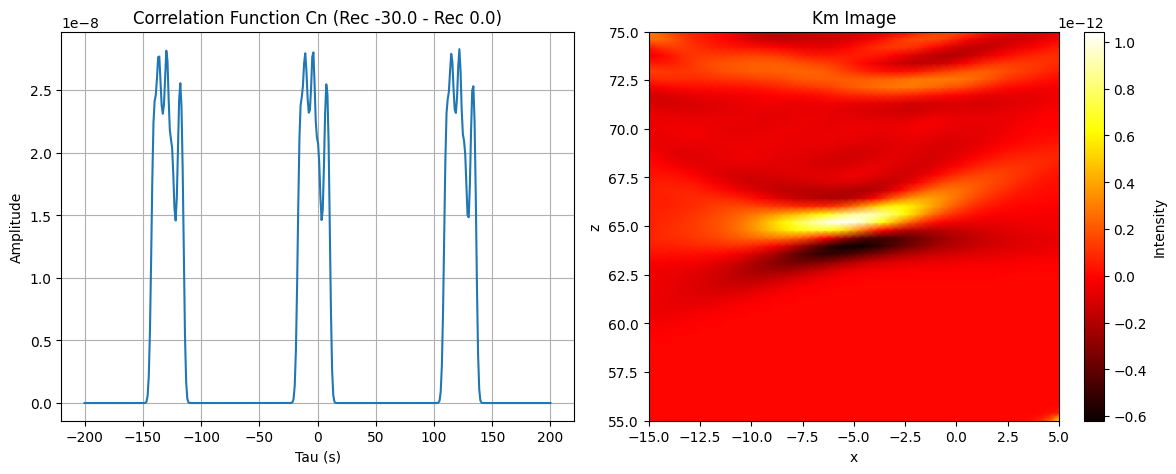

In [26]:
def G_vec(w, x, y_array):
    """Green's function from point x to many points y_array"""
    # Direct Path
    d_xy = np.linalg.norm(y_array - x, axis=1)
    G0_xy = (1.0 / (4 * np.pi * d_xy))[None, :] * np.exp(1j * w[:, None] * d_xy[None, :] / c0)

    # Reflected Path
    d_xzr = np.linalg.norm(x - zr)
    G0_xzr = (1.0/(4*np.pi*d_xzr)) * np.exp(1j * w * d_xzr / c0)
    
    d_zry = np.linalg.norm(y_array - zr, axis=1)
    G0_zry = (1.0/(4*np.pi*d_zry)[None, :]) * np.exp(1j * w[:, None] * d_zry[None, :] / c0)
    
    return G0_xy + sigma_r * (w**2)[:, None] * G0_xzr[:, None] * G0_zry

def get_correlation_spectrum(x1, x2):
    """
    The heart of the code. 
    Calculates the Cross-Correlation Spectrum H(w) for any two points.
    Sums over all noise sources.
    """
    # 1. Get Fields from all sources to x1 and x2
    G1 = G_vec(omegas, x1, sources) # Shape (Nw, N_sources)
    G2 = G_vec(omegas, x2, sources)
    
    # 2. Multiply and Sum over Sources (The heavy loop is replaced by axis=1)
    # H(w) = Sum_s [ F(w) * G*(x1,s) * G(x2,s) ]
    H_w = np.sum(F(omegas)[:, None] * np.conj(G1) * G2, axis=1)
    
    return H_w / (2 * np.pi * N_sources)

# --- 3. Use Case A: Plotting 1D Curve (Cn) ---

def plot_Cn(tau_array, x1, x2):
    # 1. Get the spectrum (Physics)
    H_w = get_correlation_spectrum(x1, x2)
    
    # 2. Integrate over frequency (Math)
    # exp(-i * w * tau)
    phase = np.exp(-1j * omegas[:, None] * tau_array[None, :])
    Cn_values = np.real(np.dot(H_w, phase) * dw)
    
    # Plot
    plt.plot(tau_array, Cn_values)
    plt.title(f"Correlation Function Cn (Rec {x1[0]} - Rec {x2[0]})")
    plt.xlabel("Tau (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)

# --- 4. Use Case B: plotting 2D Map (Km) ---

def run_Km_simulation():
    print("Computing Image...")
    # Grid Setup
    x_range = np.linspace(-15, 5, 50)
    z_range = np.linspace(55, 75, 50)
    X, Z = np.meshgrid(x_range, z_range)
    
    # Flatten Grid
    grid_points = np.stack([X.ravel(), np.zeros(X.size), Z.ravel()], axis=1)
    Intensity_flat = np.zeros(X.size)
    
    # Loop over receivers (Reuse the Physics Function)
    for j in range(n_receivers):
        for l in range(n_receivers):
            # 1. Get the spectrum for this pair (Reuse Logic!)
            H_w = get_correlation_spectrum(receivers[j], receivers[l])
            
            # 2. Apply to Grid
            d = np.linalg.norm(grid_points - receivers[j], axis=1) + \
                np.linalg.norm(grid_points - receivers[l], axis=1)
            
            phase = np.exp(-1j * omegas[:, None] * d[None, :] / c0)
            Intensity_flat += np.real(np.dot(H_w, phase) * dw)
            
    # Plot
    Intensity = Intensity_flat.reshape(X.shape)
    plt.pcolormesh(X, Z, Intensity, shading='gouraud', cmap='hot')
    plt.colorbar(label='Intensity')
    plt.title('Km Image')
    plt.xlabel('x')
    plt.ylabel('z')

# --- 5. Run Everything ---

plt.figure(figsize=(12, 5))

# Plot Curve
plt.subplot(1, 2, 1)
taus = np.linspace(-200, 200, 400)
plot_Cn(taus, receivers[0], receivers[4])

# Plot Map
plt.subplot(1, 2, 2)
run_Km_simulation()

plt.tight_layout()
plt.show()

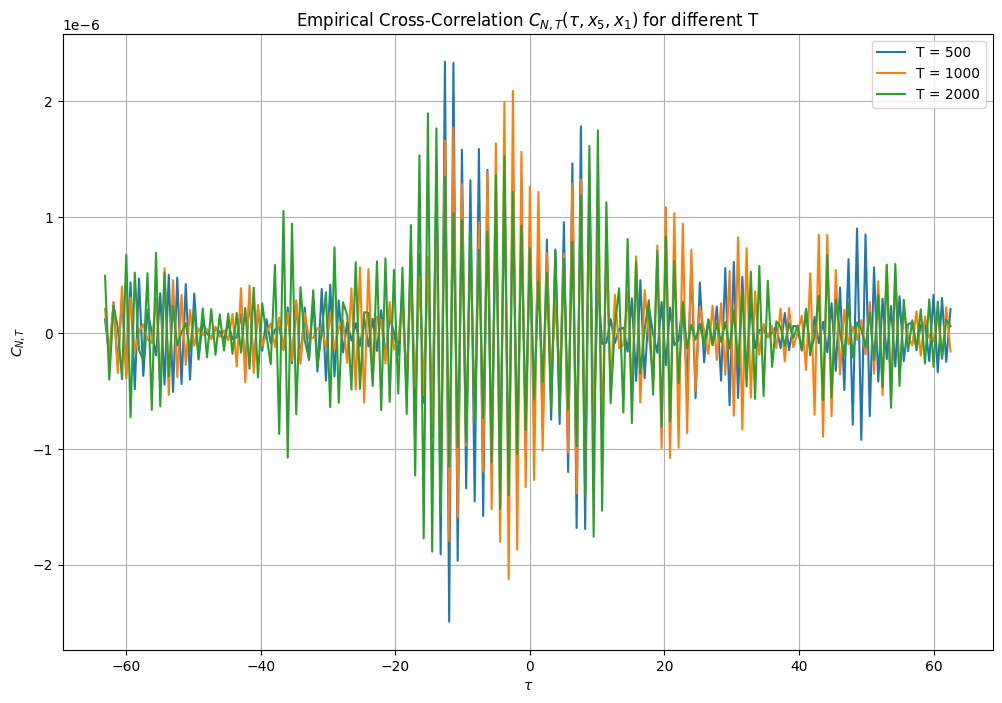

In [29]:

def compute_CNT(T, x_idx1, x_idx2, M=5):
    """
    Computes averaged Empirical Cross-Correlation for time T over M realizations.
    """
    x1 = receivers[x_idx1]
    x2 = receivers[x_idx2]
    
    # Precompute Green's functions for all sources to these two receivers
    G1 = np.array([G(omegas, x1, s) for s in sources]) # (N_sources, N_omegas)
    G2 = np.array([G(omegas, x2, s) for s in sources])
    
    all_correlations = []
    
    for m in range(M):
        # Generate random noise in frequency domain: n_hat = sqrt(F_hat) * random_phase
        # Each source is independent
        u1_w = np.zeros(len(omegas), dtype=complex)
        u2_w = np.zeros(len(omegas), dtype=complex)
        
        for s in range(N_sources):
            random_phase = np.exp(1j * np.random.uniform(0, 2*np.pi, len(omegas)))
            n_hat = np.sqrt(F(omegas)) * random_phase
            u1_w += G1[s] * n_hat
            u2_w += G2[s] * n_hat
        
        # Transform to Time Domain using IFFT
        u1_t = np.fft.ifftshift(np.fft.ifft(u1_w)).real
        u2_t = np.fft.ifftshift(np.fft.ifft(u2_w)).real
        
        # Compute correlation using numpy.correlate
        # 'full' mode gives a result of size len(u1)+len(u2)-1
        corr = np.correlate(u2_t, u1_t, mode='same')
        all_correlations.append(corr)
    
    # Average over M realizations for stability (Question 2.a)
    avg_corr = np.mean(all_correlations, axis=0)
    
    # Define tau axis centered at 0
    # dt = 2*pi / (range_of_omega)
    dt = 2 * np.pi / (omegas[-1] - omegas[0])
    tau_axis = np.arange(-len(avg_corr)//2, len(avg_corr)//2) * dt
    
    return tau_axis, avg_corr

# --- 4. Plotting for different T values ---
T_values = [500, 1000, 2000]
plt.figure(figsize=(12, 8))

for T in T_values:
    # Note: In a real FFT, T is related to the frequency resolution. 
    # To simulate longer T, we use more realizations M or a finer dw.
    tau, c_nt = compute_CNT(T, 4, 0, M=10)
    
    # Filter for tau in [-150, 150]
    mask = (tau >= -150) & (tau <= 150)
    plt.plot(tau[mask], c_nt[mask], label=f'T = {T}')

plt.title("Empirical Cross-Correlation $C_{N,T}(\\tau, x_5, x_1)$ for different T")
plt.xlabel("$\\tau$")
plt.ylabel("$C_{N,T}$")
plt.legend()
plt.grid(True)
plt.show()

Simulating T=500 with M=15 realizations...


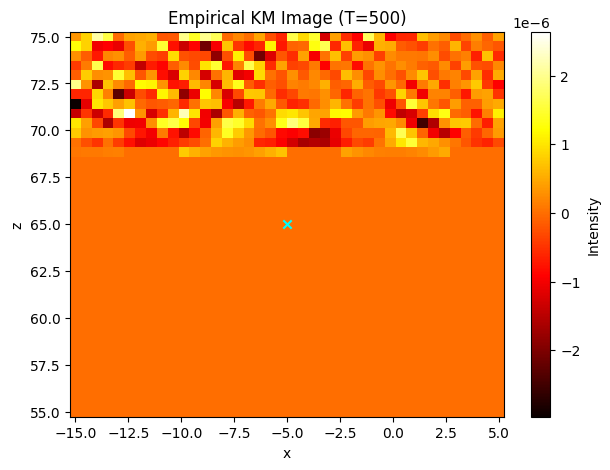

Simulating T=2000 with M=15 realizations...


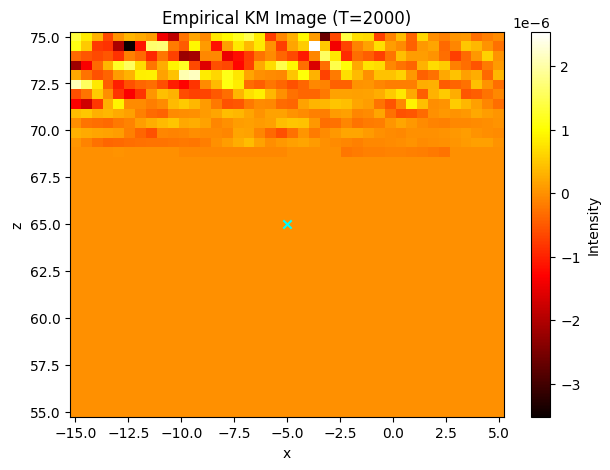

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Precompute all empirical cross-correlations ---
# We need to compute CNT for EVERY pair of receivers (j, l)
# To make it fast, we simulate u(t, xj) for all 5 receivers once.

def get_all_CNT(T, M=20):
    dt = 2 * np.pi / (omegas[-1] - omegas[0])
    # Store correlations for all pairs (j, l)
    cnt_data = {}
    
    # Precompute Green's functions for all 5 receivers
    G_all_rec = [np.array([G(omegas, receivers[j], s) for s in sources]) 
                 for j in range(n_receivers)]

    # Initialize storage for average
    for j in range(n_receivers):
        for l in range(n_receivers):
            cnt_data[(j, l)] = 0.0

    print(f"Simulating T={T} with M={M} realizations...")
    for m in range(M):
        # Generate noise and signals for this realization
        u_w = [np.zeros(len(omegas), dtype=complex) for _ in range(n_receivers)]
        for s in range(N_sources):
            random_phase = np.exp(1j * np.random.uniform(0, 2*np.pi, len(omegas)))
            n_hat = np.sqrt(F(omegas)) * random_phase
            for j in range(n_receivers):
                u_w[j] += G_all_rec[j][s] * n_hat
        
        # Transform all to time domain
        u_t = [np.fft.ifftshift(np.fft.ifft(uw)).real for uw in u_w]
        
        # Correlate all pairs
        for j in range(n_receivers):
            for l in range(n_receivers):
                cnt_data[(j, l)] += np.correlate(u_t[l], u_t[j], mode='same')
    
    # Average and create interpolation functions
    from scipy.interpolate import interp1d
    tau_axis = np.arange(-len(u_t[0])//2, len(u_t[0])//2) * dt
    
    cnt_funcs = {}
    for key in cnt_data:
        avg_val = cnt_data[key] / M
        # Create a lookup function for any tau
        cnt_funcs[key] = interp1d(tau_axis, avg_val, bounds_error=False, fill_value=0)
        
    return cnt_funcs

# --- 2. Compute KM Image using Empirical Data ---
def compute_KM_empirical(cnt_funcs, x_search, z_search):
    Intensity = np.zeros((len(z_search), len(x_search)))
    for i, xs in enumerate(x_search):
        for k, zs in enumerate(z_search):
            y_search = np.array([xs, 0, zs])
            val = 0
            for j in range(n_receivers):
                for l in range(n_receivers):
                    # Travel time lag
                    tau = (np.linalg.norm(receivers[j] - y_search) + 
                           np.linalg.norm(y_search - receivers[l])) / c0
                    val += cnt_funcs[(j, l)](tau)
            Intensity[k, i] = val
    return Intensity

# --- 3. Run and Plot ---
x_grid = np.linspace(-15, 5, 40)
z_grid = np.linspace(55, 75, 40)

# Compare T = 500 and T = 2000
for T_test in [500, 2000]:
    cnt_funcs = get_all_CNT(T_test, M=15)
    img = compute_KM_empirical(cnt_funcs, x_grid, z_grid)
    
    plt.figure(figsize=(7, 5))
    plt.pcolormesh(x_grid, z_grid, img, shading='auto', cmap='hot')
    plt.colorbar(label='Intensity')
    plt.scatter(zr[0], zr[2], color='cyan', marker='x', label='Reflector')
    plt.title(f"Empirical KM Image (T={T_test})")
    plt.xlabel("x")
    plt.ylabel("z")
    plt.show()

Generating signals and correlating for T=1000, M=20...


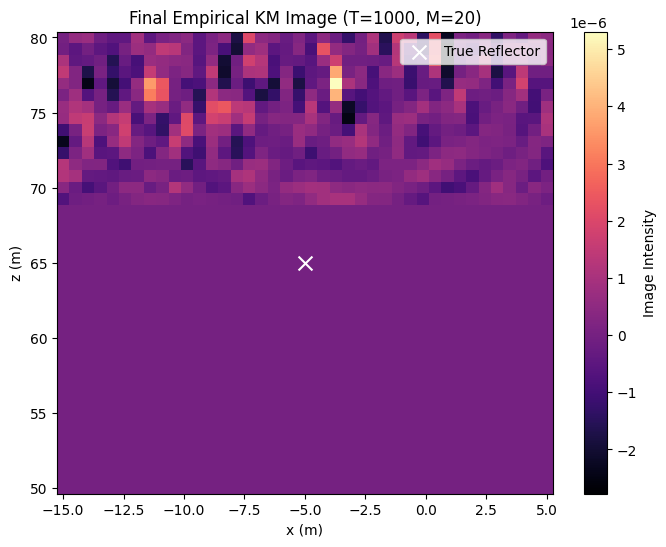

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. Simulation for a specific T and M ---
T = 1000  # Total recording time
M = 20    # Number of averaging windows for stability
dt = 2 * np.pi / (omegas[-1] - omegas[0])

# Precompute Green's functions for all 5 receivers
G_rec = [np.array([G(omegas, receivers[j], s) for s in sources]) 
         for j in range(n_receivers)]

# Storage for the summed correlations
cnt_summed = {}
for j in range(n_receivers):
    for l in range(n_receivers):
        cnt_summed[(j, l)] = 0.0

print(f"Generating signals and correlating for T={T}, M={M}...")
for m in range(M):
    # Signals in frequency domain
    u_w = [np.zeros(len(omegas), dtype=complex) for _ in range(n_receivers)]
    for s in range(N_sources):
        # Independent random phase for each source
        phi = np.exp(1j * np.random.uniform(0, 2*np.pi, len(omegas)))
        noise_hat = np.sqrt(F(omegas)) * phi
        for j in range(n_receivers):
            u_w[j] += G_rec[j][s] * noise_hat
    
    # Time domain signals
    u_t = [np.fft.ifftshift(np.fft.ifft(uw)).real for uw in u_w]
    
    # Compute all 25 cross-correlation pairs
    for j in range(n_receivers):
        for l in range(n_receivers):
            cnt_summed[(j, l)] += np.correlate(u_t[l], u_t[j], mode='same')

# 2. Setup interpolation and KM Grid
tau_axis = np.arange(-len(u_t[0])//2, len(u_t[0])//2) * dt
cnt_funcs = {key: interp1d(tau_axis, val/M, bounds_error=False, fill_value=0) 
             for key, val in cnt_summed.items()}

x_grid = np.linspace(-15, 5, 40)
z_grid = np.linspace(50, 80, 40)
KM_Image = np.zeros((len(z_grid), len(x_grid)))

# 3. Imaging Functional
for i, xs in enumerate(x_grid):
    for k, zs in enumerate(z_grid):
        ys = np.array([xs, 0, zs])
        val = 0
        for j in range(n_receivers):
            for l in range(n_receivers):
                # Distance-to-time mapping (c0=1)
                tau = (np.linalg.norm(receivers[j] - ys) + np.linalg.norm(ys - receivers[l]))
                val += cnt_funcs[(j, l)](tau)
        KM_Image[k, i] = val

# 4. Final Plot
plt.figure(figsize=(8, 6))
plt.pcolormesh(x_grid, z_grid, KM_Image, shading='auto', cmap='magma')
plt.colorbar(label='Image Intensity')
plt.scatter(zr[0], zr[2], color='white', marker='x', s=100, label='True Reflector')
plt.title(f"Final Empirical KM Image (T={T}, M={M})")
plt.xlabel("x (m)")
plt.ylabel("z (m)")
plt.legend()
plt.show()